# Tugas Praktikum 1: Scraping & Eksplorasi Data
Sumber Data: Tutiempo.net (Data Cuaca Historis Jakarta)

## 1. Scraping Dataset
- **Sumber Data**: en.tutiempo.net/climate/indonesia.html (Jakarta Observatory).
- **Library**: `requests` dan `BeautifulSoup`.
- **Penyimpanan**: Hasil mentah disimpan ke `dataset_cuaca.csv` agar proses scraping tidak diulang.

In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fungsi mengambil data cuaca harian per bulan
def scrape_tutiempo_month(year, month):
    url = f"https://en.tutiempo.net/climate/{month:02d}-{year}/ws-967450.html"
    try:
        response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=10)
        if response.status_code != 200:
            return []
        
        soup = BeautifulSoup(response.text, 'html.parser')
        table = soup.find('table', {'class': 'medias'})
        if not table:
            return []
            
        rows = table.find_all('tr')[1:] # Lewati header tabel
        month_data = []
        for row in rows:
            cols = row.find_all('td')
            if len(cols) >= 15:
                day = cols[0].text.strip()
                if not day.isdigit(): 
                    continue # Hanya ambil data harian
                    
                t = cols[1].text.strip()    # Average Temperature
                tm = cols[2].text.strip()   # Max Temperature
                tmin = cols[3].text.strip() # Min Temperature
                h = cols[5].text.strip()    # Humidity
                vv = cols[7].text.strip()   # Visibility
                v = cols[8].text.strip()    # Wind Speed
                
                # Cek Indikator Hujan (ada icon img atau teks RA)
                ra_indicator = "Ya" if cols[11].find('img') or cols[11].text.strip() != "" else "Tidak"
                
                month_data.append([f"{year}-{month:02d}-{day.zfill(2)}", t, tm, tmin, h, v, vv, ra_indicator])
                
        return month_data
    except:
        return []

# Jika Anda ingin scraping ulang, ubah ke True.
# (Diset False agar saat Run All kita hanya memuat dari CSV yang sudah ada)
JALANKAN_SCRAPING = False 

if JALANKAN_SCRAPING:
    all_data = []
    print("Proses scraping sedang berjalan...")
    for year in range(2019, 2024):
        for month in range(1, 13):
            all_data.extend(scrape_tutiempo_month(year, month))
            time.sleep(0.5)

    columns = ['Tanggal', 'Suhu Rata-rata', 'Suhu Maksimum', 'Suhu Minimum', 'Kelembapan', 'Kecepatan Angin', 'Jarak Pandang', 'Hujan']
    df_raw = pd.DataFrame(all_data, columns=columns)
    df_raw.to_csv('dataset_cuaca.csv', index=False)
    print("Scraping selesai! Data disimpan ke 'dataset_cuaca.csv'")
else:
    print("Membaca dataset langsung dari 'dataset_cuaca.csv'")


Membaca dataset langsung dari 'dataset_cuaca.csv'


## 2. Import dan Pemahaman Dataset

In [12]:
# Impor dataset menggunakan pandas. 
# (na_values='-' digunakan karena Tutiempo memakai strip untuk melambangkan sel kosong/Missing Value)
df = pd.read_csv('dataset_cuaca.csv', na_values='-')

print("5 Baris Pertama Dataset:")
display(df.head())

5 Baris Pertama Dataset:


,Tanggal,Suhu Rata-rata,Suhu Maksimum,Suhu Minimum,Kelembapan,Kecepatan Angin,Jarak Pandang,Hujan
0,2019-01-01,26.3,30.4,24.0,82.0,6.3,6.1,Ya
1,2019-01-02,28.2,33.0,24.2,74.0,9.4,6.4,Ya
2,2019-01-03,29.0,33.4,24.6,66.0,9.6,6.4,Tidak
3,2019-01-04,29.9,33.8,24.8,61.0,10.9,7.1,Tidak
4,2019-01-05,29.1,33.4,26.4,71.0,3.9,6.4,Tidak


In [13]:
# Tampilkan info umum
print(f"Bentuk Dataset (Shape): {df.shape}\n")
print("Tipe Data (dtypes):")
display(df.dtypes)
print("\nInformasi Umum (.info()):")
df.info()

Bentuk Dataset (Shape): (1826, 8)

Tipe Data (dtypes):


Tanggal                str
Suhu Rata-rata     float64
Suhu Maksimum      float64
Suhu Minimum       float64
Kelembapan         float64
Kecepatan Angin    float64
Jarak Pandang      float64
Hujan                  str
dtype: object


Informasi Umum (.info()):
<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tanggal          1826 non-null   str    
 1   Suhu Rata-rata   1813 non-null   float64
 2   Suhu Maksimum    1813 non-null   float64
 3   Suhu Minimum     1813 non-null   float64
 4   Kelembapan       1813 non-null   float64
 5   Kecepatan Angin  1813 non-null   float64
 6   Jarak Pandang    1813 non-null   float64
 7   Hujan            1826 non-null   str    
dtypes: float64(6), str(2)
memory usage: 114.3 KB


### Identifikasi Tipe Atribut:
1. **Tanggal**: Nominal (Kategorikal penanda waktu)
2. **Suhu Rata-rata**: Numerik Kontinu
3. **Suhu Maksimum**: Numerik Kontinu
4. **Suhu Minimum**: Numerik Kontinu
5. **Kelembapan**: Numerik Kontinu (Persentase)
6. **Kecepatan Angin**: Numerik Kontinu
7. **Jarak Pandang**: Numerik Kontinu
8. **Hujan**: Kategorikal Nominal (Binary: Ya / Tidak) - *Target Analisis*

## 3. Analisis Statistik dan Kualitas Data

In [14]:
numeric_cols = ['Suhu Rata-rata', 'Suhu Maksimum', 'Suhu Minimum', 'Kelembapan', 'Kecepatan Angin', 'Jarak Pandang']

# Rata-rata, standar deviasi, nilai min/maks sudah ada di describe()
statistik = df[numeric_cols].describe().T

# Tambahkan perhitungan Median dan Modus
statistik['median'] = df[numeric_cols].median()
statistik['modus'] = df[numeric_cols].mode().iloc[0]

print("Statistik Deskriptif Atribut Numerik:")
display(statistik)

Statistik Deskriptif Atribut Numerik:


,count,mean,std,min,25%,50%,75%,max,median,modus
Suhu Rata-rata,1813.0,28.756867,1.041063,25.0,28.1,28.9,29.5,31.8,28.9,29.3
Suhu Maksimum,1813.0,32.361666,1.391159,27.0,31.6,32.6,33.4,36.8,32.6,32.4
Suhu Minimum,1813.0,25.712300,0.930972,21.7,25.0,25.8,26.4,28.2,25.8,25.0
Kelembapan,1813.0,74.789851,6.367209,52.0,71.0,75.0,79.0,95.0,75.0,72.0
Kecepatan Angin,1813.0,4.968505,2.361063,0.0,3.5,4.6,6.1,33.9,4.6,3.5
Jarak Pandang,1813.0,6.291009,0.214105,5.3,6.1,6.4,6.4,7.1,6.4,6.4


In [15]:
# Hitung frekuensi/distribusi untuk atribut kategorikal
print("Distribusi Atribut Kategorikal (Hujan):")
display(df['Hujan'].value_counts().to_frame())

Distribusi Atribut Kategorikal (Hujan):


,count
Hujan,
Tidak,1161
Ya,665


In [16]:
# Identifikasi jumlah nilai yang hilang (Missing Values)
print("Jumlah Nilai Hilang (Missing Values) per Atribut sebelum dibersihkan:")
display(df.isnull().sum().to_frame(name='Jumlah Missing Values'))

Jumlah Nilai Hilang (Missing Values) per Atribut sebelum dibersihkan:


,Jumlah Missing Values
Tanggal,0
Suhu Rata-rata,13
Suhu Maksimum,13
Suhu Minimum,13
Kelembapan,13
Kecepatan Angin,13
Jarak Pandang,13
Hujan,0


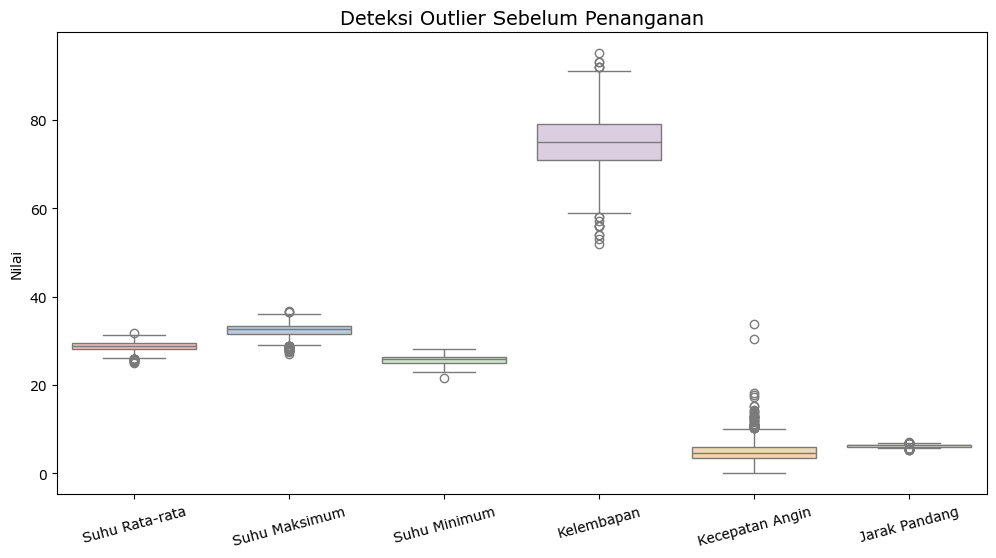

In [17]:
# Deteksi outlier pada atribut numerik
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols], palette="Pastel1")
plt.title("Deteksi Outlier Sebelum Penanganan", fontsize=14)
plt.ylabel("Nilai")
plt.xticks(rotation=15)
plt.show()

**Evaluasi Kualitas Data:** Terdapat Missing Values pada atribut numerik dan terlihat titik-titik ekstrim (Outlier) khususnya pada Jarak Pandang dan Kecepatan Angin (titik yang melewati garis batas boxplot).

### 3.1 Penanganan Nilai Hilang dan Outlier
Sesuai hasil deteksi di atas, kita akan melakukan data cleaning dengan perlakuan khusus:
1. **Missing Values**: Menggunakan metode matematis **Interpolasi Linear** untuk data numerik (karena cuaca adalah data *time-series* yang berkesinambungan). Untuk atribut kategorikal menggunakan **Modus**.
2. **Outlier**: Menggunakan metode penandaan **IQR (Interquartile Range)** lalu menjepit (Capping) nilai ekstrem tersebut ke batas wajar maksimum dan minimum, agar analisis statistik selanjutnya tidak terdistorsi.

In [18]:
# 1. PENANGANAN MISSING VALUES (Interpolasi Linear)
df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit_direction='both')

# Jika kebetulan kolom 'Hujan' (kategorik) ada yang kosong, isi dengan modus
if df['Hujan'].isnull().sum() > 0:
    modus_hujan = df['Hujan'].mode()[0]
    df['Hujan'].fillna(modus_hujan, inplace=True)

# 2. PENANGANAN OUTLIER (IQR Capping)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping: Timpa angka yang melewati batas wajar
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Jumlah Missing Values setelah Penanganan:")
display(df.isnull().sum().to_frame(name='Jumlah Missing Values'))

Jumlah Missing Values setelah Penanganan:


,Jumlah Missing Values
Tanggal,0
Suhu Rata-rata,0
Suhu Maksimum,0
Suhu Minimum,0
Kelembapan,0
Kecepatan Angin,0
Jarak Pandang,0
Hujan,0


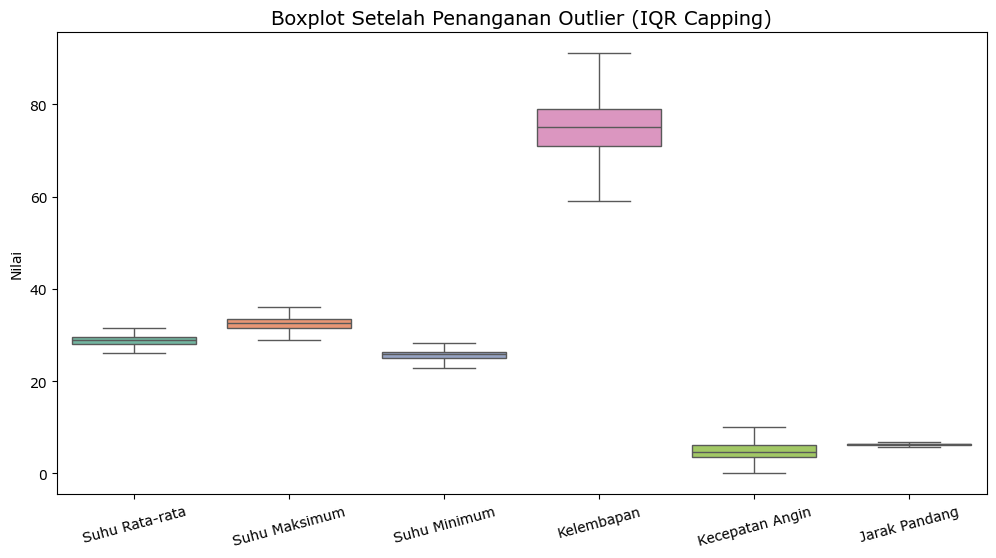

In [19]:
# Memastikan Outlier sudah tertangani dengan Boxplot baru
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols], palette="Set2")
plt.title("Boxplot Setelah Penanganan Outlier (IQR Capping)", fontsize=14)
plt.ylabel("Nilai")
plt.xticks(rotation=15)
plt.show()

## 4. Visualisasi Data

C:\Users\ahmad\AppData\Local\Temp\ipykernel_20144\2412853676.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Hujan', ax=axes[1], palette='viridis')


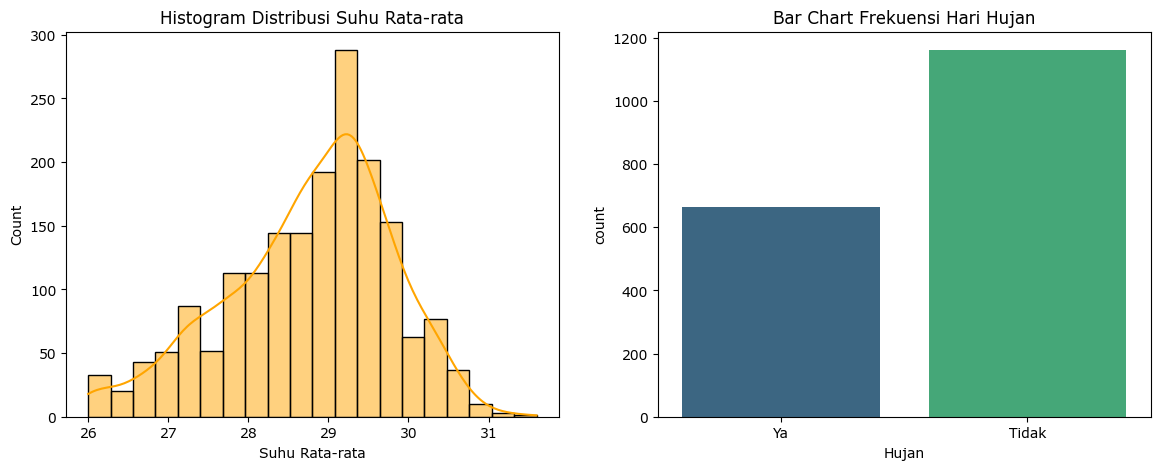

In [20]:
# Univariat: histogram/distribusi untuk atribut numerik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Suhu Rata-rata'], bins=20, kde=True, ax=axes[0], color='orange')
axes[0].set_title('Histogram Distribusi Suhu Rata-rata')

# Univariat: bar chart untuk atribut kategorikal
sns.countplot(data=df, x='Hujan', ax=axes[1], palette='viridis')
axes[1].set_title('Bar Chart Frekuensi Hari Hujan')
plt.show()

**Interpretasi:**  
- **Suhu**: Sebagian besar hari di Jakarta terpusat di suhu sangat hangat (sekitar 29°C), menunjukkan bentuk lonceng distribusi normal.
- **Hujan**: Sepanjang 5 tahun (2019-2023), jumlah hari kering tanpa hujan mendominasi signifikan.

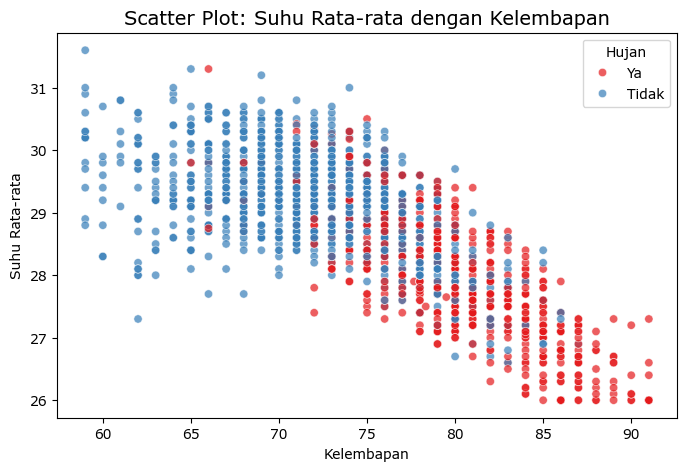

In [21]:
# Bivariat/hubungan antar atribut: scatter plot dua atribut numerik
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Kelembapan', y='Suhu Rata-rata', hue='Hujan', palette='Set1', alpha=0.7)
plt.title('Scatter Plot: Suhu Rata-rata dengan Kelembapan', fontsize=14)
plt.show()

**Interpretasi:**  
Terdapat relasi negatif antara Suhu dan Kelembapan; ketika tingkat kelembapan udara meninggi mendekati 100%, suhu udara akan cenderung menjadi lebih sejuk, dan fenomena ini paling sering terjadi bersamaan saat hujan turun (titik merah).

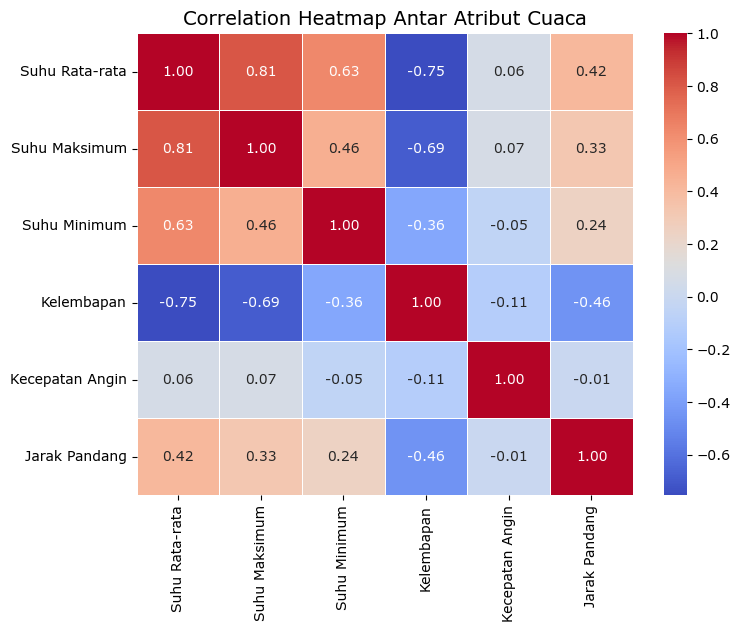

In [22]:
# Bivariat/hubungan antar atribut: correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap Antar Atribut Cuaca', fontsize=14)
plt.show()

**Interpretasi:**  
- Seluruh kelompok Suhu (Maksimum, Minimum, Rata-rata) memiliki hubungan korelasi positif yang sangat linear dan kuat.
- Kecepatan angin dan Jarak pandang hampir tidak memiliki korelasi linear yang berarti terhadap suhu dan kelembapan (bernilai mendekati 0).